# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

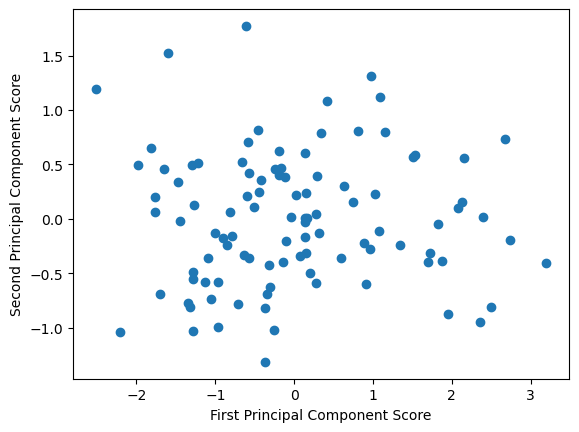

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The distribution of the data is random, indicating there is no dominant direction of variance or clusters. Three points sit away from the main plot, indicating outliers.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

**Import Libraries**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, RepeatedKFold

**Load Data**

In [3]:
diabetes_indicators = pd.read_csv('Modified_Datasets/diabetes_indicators.csv')
obesity = pd.read_csv('Modified_Datasets/obesity.csv')
cervical_cancer = pd.read_csv('Modified_Datasets/cervical_cancer.csv')

In [4]:
# Heatmaps

<Axes: >

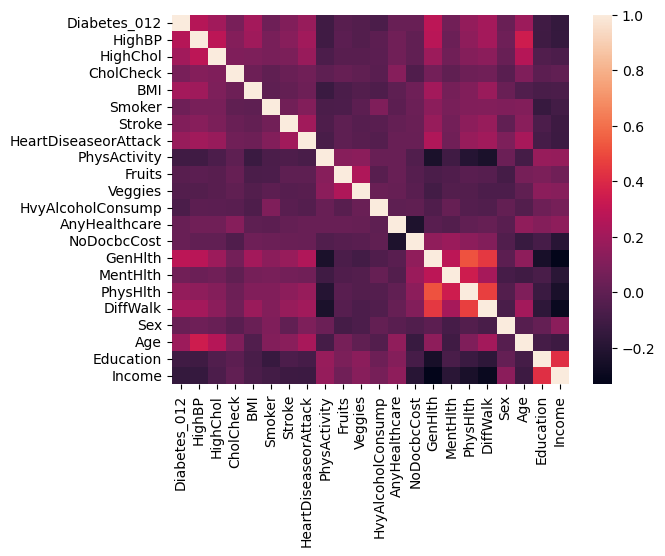

In [5]:
sns.heatmap(diabetes_indicators.corr())

In [6]:
diabetes_indicators.corr()['Diabetes_012'].drop('Diabetes_012').sort_values(ascending=False)

GenHlth                 0.284881
HighBP                  0.261976
BMI                     0.212027
DiffWalk                0.210638
HighChol                0.203327
Age                     0.184642
HeartDiseaseorAttack    0.170816
PhysHlth                0.160485
Stroke                  0.100276
CholCheck               0.075701
MentHlth                0.057698
Smoker                  0.046774
Sex                     0.032243
AnyHealthcare           0.024911
NoDocbcCost             0.023568
Fruits                 -0.025462
Veggies                -0.043446
HvyAlcoholConsump      -0.067164
PhysActivity           -0.103408
Education              -0.107742
Income                 -0.147102
Name: Diabetes_012, dtype: float64

In [7]:
# Temporarily ordinal encode target column to see numerical correlation
print([list(obesity['Obesity Level'].unique())])
categories = [['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']]

encoder = OrdinalEncoder(categories = categories, dtype = int)
obesity['Obesity_Encoded'] = encoder.fit_transform(obesity[['Obesity Level']])

print(obesity[['Obesity Level', 'Obesity_Encoded']].head(10))

[['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']]
         Obesity Level  Obesity_Encoded
0        Normal_Weight                1
1        Normal_Weight                1
2        Normal_Weight                1
3   Overweight_Level_I                2
4  Overweight_Level_II                3
5        Normal_Weight                1
6        Normal_Weight                1
7        Normal_Weight                1
8        Normal_Weight                1
9        Normal_Weight                1


<Axes: >

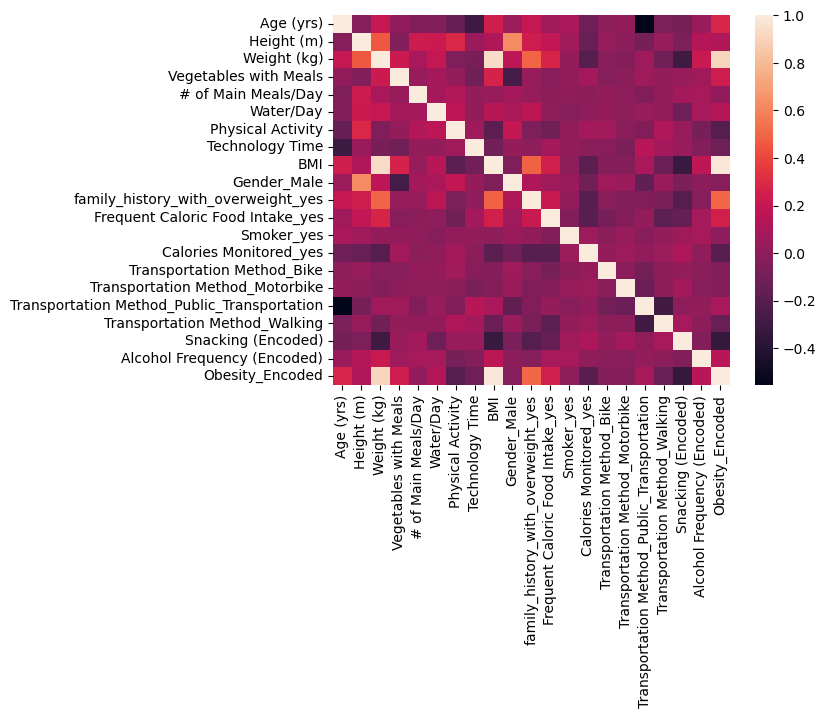

In [8]:
sns.heatmap(obesity.select_dtypes(include = 'number').corr())

In [9]:
obesity.select_dtypes(include = 'number').corr()['Obesity_Encoded'].drop('Obesity_Encoded').sort_values(ascending=False)

BMI                                            0.977812
Weight (kg)                                    0.912453
family_history_with_overweight_yes             0.503374
Age (yrs)                                      0.279231
Frequent Caloric Food Intake_yes               0.249927
Vegetables with Meals                          0.228591
Alcohol Frequency (Encoded)                    0.155300
Water/Day                                      0.134170
Height (m)                                     0.124863
Transportation Method_Public_Transportation    0.089861
# of Main Meals/Day                            0.011034
Smoker_yes                                     0.001984
Gender_Male                                   -0.031920
Transportation Method_Bike                    -0.037260
Transportation Method_Motorbike               -0.038182
Technology Time                               -0.115323
Transportation Method_Walking                 -0.139032
Calories Monitored_yes                        -0

<Axes: >

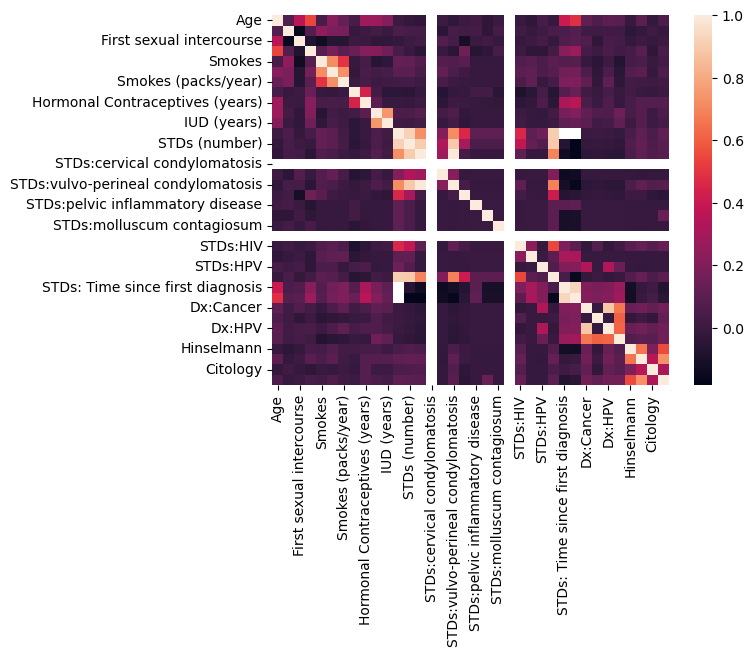

In [10]:
sns.heatmap(cervical_cancer.corr())

In [11]:
cervical_cancer.corr()['Dx:Cancer'].drop('Dx:Cancer').sort_values(ascending=False)

Dx:HPV                                0.886441
Dx                                    0.665423
STDs:HPV                              0.329675
STDs: Time since last diagnosis       0.212983
STDs: Time since first diagnosis      0.201319
Biopsy                                0.162142
Schiller                              0.158419
Hinselmann                            0.133550
Citology                              0.114660
Smokes (packs/year)                   0.110852
IUD                                   0.109539
Age                                   0.108519
IUD (years)                           0.097186
First sexual intercourse              0.066572
Smokes (years)                        0.055122
Hormonal Contraceptives (years)       0.053014
Num of pregnancies                    0.032440
Hormonal Contraceptives               0.023522
Number of sexual partners             0.020326
STDs                                  0.001856
STDs:pelvic inflammatory disease     -0.005848
STDs:genital 

In [12]:
# Bubble plots

In [13]:
pd.set_option('display.max_columns', None)
diabetes_indicators.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4


<Axes: xlabel='Age', ylabel='BMI'>

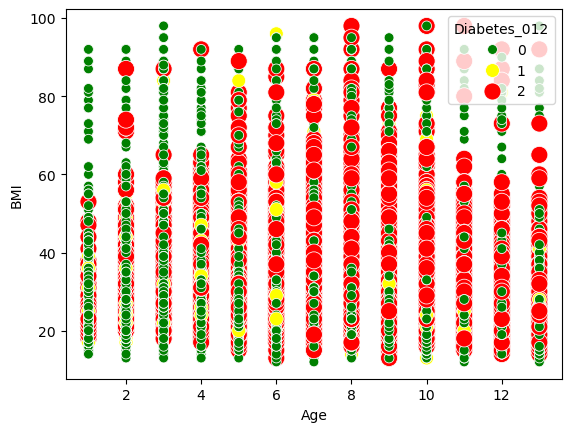

In [14]:
sns.scatterplot(
    x = 'Age',
    y = 'BMI',
    data = diabetes_indicators,
    size = 'Diabetes_012',
    sizes = (50, 150),
    hue = 'Diabetes_012',
    hue_order = [0, 1, 2],
    palette = ['green', 'yellow', 'red']
)

In [15]:
obesity.head()

,Age (yrs),Height (m),Weight (kg),Vegetables with Meals,# of Main Meals/Day,Water/Day,Physical Activity,Technology Time,Obesity Level,BMI,Gender_Male,family_history_with_overweight_yes,Frequent Caloric Food Intake_yes,Smoker_yes,Calories Monitored_yes,Transportation Method_Bike,Transportation Method_Motorbike,Transportation Method_Public_Transportation,Transportation Method_Walking,Snacking (Encoded),Alcohol Frequency (Encoded),Obesity_Encoded
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,Normal_Weight,24.386526,0,1,0,0,0,0,0,1,0,1,0,1
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,Normal_Weight,24.238227,0,1,0,1,1,0,0,1,0,1,1,1
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,Normal_Weight,23.765432,1,1,0,0,0,0,0,1,0,1,2,1
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,Overweight_Level_I,26.851852,1,0,0,0,0,0,0,0,1,1,2,2
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,Overweight_Level_II,28.342381,1,0,0,0,0,0,0,1,0,1,1,3


<Axes: xlabel='Age (yrs)', ylabel='Weight (kg)'>

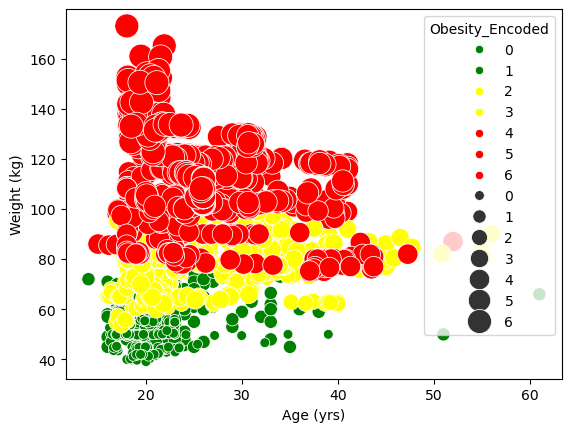

In [16]:
sns.scatterplot(
    x = 'Age (yrs)',
    y = 'Weight (kg)',
    data = obesity,
    size = 'Obesity_Encoded',
    sizes = (50, 300),
    hue = 'Obesity_Encoded',
    hue_order = [0, 1, 2, 3, 4, 5, 6],
    palette = ['green', 'green', 'yellow', 'yellow', 'red', 'red', 'red']
)

<Axes: xlabel='STDs: Time since first diagnosis', ylabel='STDs (number)'>

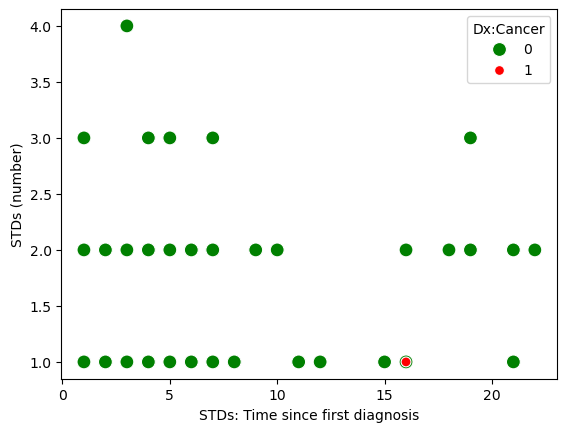

In [17]:
sns.scatterplot(
    x = 'STDs: Time since first diagnosis',
    y = 'STDs (number)',
    data = cervical_cancer,
    size = 'Dx:Cancer',
    sizes = (50, 100),
    hue = 'Dx:Cancer',
    hue_order = [0, 1],
    palette = ['green', 'red']
)

In [18]:
# PCA

**Diabetes**

In [19]:
X = diabetes_indicators.drop('Diabetes_012', axis = 1)
y = diabetes_indicators['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = PCA()
model.fit_transform(X_train)

for component in range(0,5):
    print(f"The % variance explained by component #{component + 1} is {model.explained_variance_ratio_[component]*100:.2f}%.")

The % variance explained by component #1 is 48.06%.
The % variance explained by component #2 is 22.00%.
The % variance explained by component #3 is 21.70%.
The % variance explained by component #4 is 4.54%.
The % variance explained by component #5 is 2.03%.


**Obesity**

In [20]:
X = obesity.drop(['Obesity Level', 'Obesity_Encoded'], axis = 1)
y = obesity[['Obesity Level']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = PCA()
model.fit_transform(X_train)

for component in range(0,5):
    print(f"The % variance explained by component #{component + 1} is {model.explained_variance_ratio_[component]*100:.2f}%.")

The % variance explained by component #1 is 93.62%.
The % variance explained by component #2 is 5.04%.
The % variance explained by component #3 is 0.94%.
The % variance explained by component #4 is 0.08%.
The % variance explained by component #5 is 0.07%.


**Cervical Cancer**

In [21]:
X = cervical_cancer.drop(['Dx:Cancer', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'], axis = 1)
y = cervical_cancer['Dx:Cancer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:
# Avoided imputing the data until when I needed to use test data to prevent data leakage, performing now

imputer = SimpleImputer(strategy = 'median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_test)

In [23]:
model = PCA()
model.fit_transform(X_train)

for component in range(0,5):
    print(f"The % variance explained by component #{component + 1} is {model.explained_variance_ratio_[component]*100:.2f}%.")

The % variance explained by component #1 is 61.53%.
The % variance explained by component #2 is 15.94%.
The % variance explained by component #3 is 9.55%.
The % variance explained by component #4 is 5.33%.
The % variance explained by component #5 is 2.59%.


*Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?*

For the obesity dataset, you could represent the data using only its first principal component due to the high amount of variance it captures (93.62%). For the other two datasets, the first component represents ~50% of the variance, needing one or two more components to sufficiently capture the variance.

In [24]:
# Linear regression analysis

In [25]:
X = diabetes_indicators.drop('Diabetes_012', axis = 1)
y = diabetes_indicators['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [26]:
model = LinearRegression()

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

# Scoring: R^2
cv_results = cross_val_score(model, X_train, y_train, cv = cv)

print(f"Mean R^2 is {np.mean(cv_results)*100:.2f}%.")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R^2 of model on test data is {model.score(X_test, y_test)*100:.2f}%.")

Mean R^2 is 16.41%.
R^2 of model on test data is 16.24%.


In [27]:
X = obesity.drop(['Obesity Level', 'Obesity_Encoded'], axis = 1)
y = obesity[['Obesity_Encoded']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [28]:
model = LinearRegression()

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

# Scoring: R^2
cv_results = cross_val_score(model, X_train, y_train, cv = cv)

print(f"Mean R^2 is {np.mean(cv_results)*100:.2f}%.")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R^2 of model on test data is {model.score(X_test, y_test)*100:.2f}%.")

Mean R^2 is 96.09%.
R^2 of model on test data is 96.41%.


In [29]:
X = cervical_cancer.drop(['Dx:Cancer', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'], axis = 1)
y = cervical_cancer['Dx:Cancer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

imputer = SimpleImputer(strategy = 'median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_test)

In [30]:
model = LinearRegression()

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

# Scoring: R^2
cv_results = cross_val_score(model, X_train, y_train, cv = cv)

print(f"Mean R^2 is {np.mean(cv_results)*100:.2f}%.")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R^2 of model on test data is {model.score(X_test, y_test)*100:.2f}%.")

Mean R^2 is 60.18%.
R^2 of model on test data is 86.01%.


Which features seem most likely to be useful to predict other features?

Diabetes: BMI, GenHlth   
Obesity: family history, frequent caloric intake   
Cervical cancer: HPV   

**Conclusions**   
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!   
Data is as expected and usable - distributions make logical sense, no outliers or columns with questionable values.

Do you see any outliers? (Data points that are far from the rest of the data).   
No outliers spotted.   

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?   
Yes, the datasets can be represented with fewer dimensions than usual.

Try using your correlation information from previous weeks to help choose features for linear regression.   

In [31]:
X = diabetes_indicators[['BMI']]
y = diabetes_indicators['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
model = LinearRegression()

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

# Scoring: R^2
cv_results = cross_val_score(model, X_train, y_train, cv = cv)

print(f"Mean R^2 is {np.mean(cv_results)*100:.2f}%.")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R^2 of model on test data is {model.score(X_test, y_test)*100:.2f}%.")

Mean R^2 is 4.51%.
R^2 of model on test data is 4.42%.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [33]:
from matplotlib.ticker import FuncFormatter

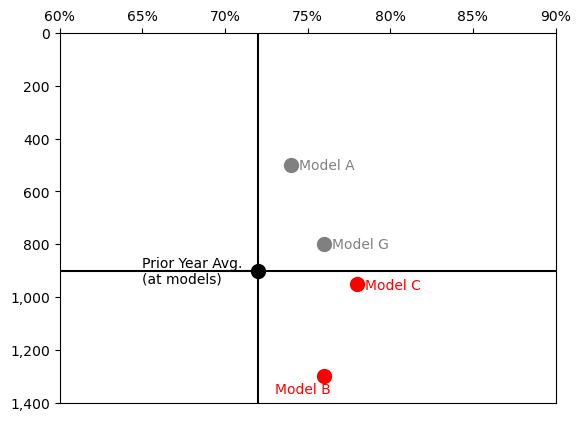

In [34]:
fig, ax = plt.subplots()

ax.set_ylim(0, 1400)
ax.set_xlim(60, 90)
ax.set_xticks(list(range(60, 91, 5)))
ax.set_yticks(list(range(0, 1401, 200)))

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))

ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")

ax.invert_yaxis()

ax.axhline(y = 900, color = 'black')
ax.axvline(x = 72, color = 'black')

plt.text(65, 888, "Prior Year Avg.")
plt.text(65, 945, "(at models)")

ax.plot(72, 900, marker = "o", markersize = 10, color = "black")

ax.plot(74, 500, marker = "o", markersize = 10, color = "gray")
plt.text(74.5, 515, "Model A", color = "gray")

ax.plot(76, 800, marker = "o", markersize = 10, color = "gray")
plt.text(76.5, 815, "Model G", color = "gray")

ax.plot(78, 950, marker = "o", markersize = 10, color = "red")
plt.text(78.5, 970, "Model C", color = "red")

ax.plot(76, 1300, marker = "o", markersize = 10, color = "red")
plt.text(73, 1365, "Model B", color = "red")

plt.show()